# Dynamic Neural Network vs Standard Neural Network Benchmark

This notebook compares the performance of **Dynamic Neural Networks (DNN)** against **Standard PyTorch MLPs** using datasets from Hugging Face's `inria-soda/tabular-benchmark`.

## Comparison Metrics
- **Accuracy** - Classification performance
- **F1-Score** - Balanced metric for imbalanced classes
- **Training Time** - Wall-clock training duration
- **Model Size** - Number of parameters

## Datasets
We benchmark on 3 classification datasets of varying sizes from the `clf_num` (numerical features) category.

In [2]:
# Setup - Install dependencies if needed
# !pip install datasets torch scikit-learn matplotlib pandas

import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Add pydnn to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', 'python'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from datasets import load_dataset

# Import Dynamic Neural Network
from pydnn import DynamicNetwork

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports successful!
PyTorch version: 2.9.1+cpu
Device: cpu


## 1. Data Loading Utilities

Functions to load and preprocess datasets from Hugging Face's tabular benchmark.

In [3]:
def load_tabular_benchmark(dataset_name, task="clf_num", test_size=0.2, seed=42):
    """
    Load a dataset from inria-soda/tabular-benchmark.
    
    Args:
        dataset_name: Name of the dataset file (without .csv)
        task: Task type ('clf_num', 'clf_cat', 'reg_num', 'reg_cat')
        test_size: Fraction for test split
        seed: Random seed
    
    Returns:
        X_train, X_test, y_train, y_test, n_classes, feature_names
    """
    # Load from HuggingFace
    data_path = f"{task}/{dataset_name}.csv"
    print(f"Loading dataset: {data_path}")
    
    dataset = load_dataset(
        "inria-soda/tabular-benchmark",
        data_files=data_path,
        split="train"
    )
    
    # Convert to pandas
    df = dataset.to_pandas()
    print(f"  Shape: {df.shape}")
    
    # Identify target column (usually last column or named 'target'/'class')
    if 'target' in df.columns:
        target_col = 'target'
    elif 'class' in df.columns:
        target_col = 'class'
    else:
        # Assume last column is target
        target_col = df.columns[-1]
    
    print(f"  Target column: {target_col}")
    
    # Split features and target
    feature_cols = [c for c in df.columns if c != target_col]
    X = df[feature_cols].values.astype(np.float32)
    y = df[target_col].values
    
    # Encode labels if needed
    if y.dtype == object or not np.issubdtype(y.dtype, np.integer):
        le = LabelEncoder()
        y = le.fit_transform(y)
    
    n_classes = len(np.unique(y))
    print(f"  Classes: {n_classes}")
    print(f"  Features: {X.shape[1]}")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    
    # Normalize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)
    
    print(f"  Train samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")
    
    return X_train, X_test, y_train, y_test, n_classes, feature_cols


def one_hot_encode(y, n_classes):
    """Convert labels to one-hot encoding."""
    return np.eye(n_classes)[y].astype(np.float32)


# Test loading a dataset
print("Testing data loading...")
X_tr, X_te, y_tr, y_te, n_cls, feat_names = load_tabular_benchmark("electricity", test_size=0.2)
print(f"\nDataset loaded successfully!")

Testing data loading...
Loading dataset: clf_num/electricity.csv


README.md: 0.00B [00:00, ?B/s]

electricity.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Shape: (38474, 8)
  Target column: class
  Classes: 2
  Features: 7
  Train samples: 30779
  Test samples: 7695

Dataset loaded successfully!


## 2. Model Definitions

### Standard PyTorch MLP
A fixed-architecture multi-layer perceptron with configurable hidden layers.

In [4]:
class StandardMLP(nn.Module):
    """
    Standard Multi-Layer Perceptron with fixed architecture.
    
    Architecture: Input -> Hidden1 (128) -> Hidden2 (64) -> Output
    Activation: ReLU for hidden layers, Softmax for output
    """
    
    def __init__(self, input_size, output_size, hidden_sizes=(128, 64)):
        super(StandardMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_sizes = hidden_sizes
    
    def forward(self, x):
        return self.network(x)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def train_pytorch_mlp(model, X_train, y_train, X_val=None, y_val=None,
                      epochs=100, lr=0.01, batch_size=64, patience=10, verbose=False):
    """
    Train a PyTorch MLP model.
    
    Returns:
        train_history: List of training losses per epoch
        val_history: List of validation losses (if validation data provided)
        training_time: Total training time in seconds
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    
    # Create DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_history = []
    val_history = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_history.append(avg_loss)
        
        # Validation
        if X_val is not None:
            model.eval()
            with torch.no_grad():
                X_val_t = torch.FloatTensor(X_val).to(device)
                y_val_t = torch.LongTensor(y_val).to(device)
                val_outputs = model(X_val_t)
                val_loss = criterion(val_outputs, y_val_t).item()
                val_history.append(val_loss)
                
                scheduler.step(val_loss)
                
                # Early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch}")
                        break
        
        if verbose and epoch % 20 == 0:
            val_str = f", val_loss={val_history[-1]:.4f}" if val_history else ""
            print(f"Epoch {epoch}: train_loss={avg_loss:.4f}{val_str}")
    
    training_time = time.time() - start_time
    
    return train_history, val_history, training_time


def predict_pytorch(model, X):
    """Get predictions from PyTorch model."""
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(device)
        outputs = model(X_t)
        _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()


# Test PyTorch MLP
print("Testing PyTorch MLP...")
test_mlp = StandardMLP(input_size=8, output_size=2, hidden_sizes=(128, 64))
print(f"Parameters: {test_mlp.count_parameters():,}")
print(f"Architecture: 8 -> 128 -> 64 -> 2")

Testing PyTorch MLP...
Parameters: 9,538
Architecture: 8 -> 128 -> 64 -> 2


## 3. Benchmark Framework

Functions to run benchmarks and collect metrics.

In [5]:
def run_single_benchmark(X_train, X_test, y_train, y_test, n_classes, seed=42, verbose=False):
    """
    Run a single benchmark comparing DNN and PyTorch MLP.
    
    Returns:
        dict with results for both models
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    input_size = X_train.shape[1]
    results = {}
    
    # Split training data for validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
    )
    
    # --- Dynamic Neural Network ---
    if verbose:
        print("\nTraining Dynamic Neural Network...")
    
    y_tr_onehot = one_hot_encode(y_tr, n_classes)
    
    dnn = DynamicNetwork(
        input_shape=(input_size,),
        output_size=n_classes,
        seed=seed,
        cost_function="CrossEntropy"
    )
    
    start_time = time.time()
    dnn_result = dnn.fit(X_tr, y_tr_onehot, verbose=False)
    dnn_train_time = time.time() - start_time
    
    # DNN predictions
    dnn_preds = np.argmax(dnn.predict(X_test), axis=1)
    dnn_accuracy = accuracy_score(y_test, dnn_preds)
    dnn_f1 = f1_score(y_test, dnn_preds, average='weighted')
    
    results['DNN'] = {
        'accuracy': dnn_accuracy,
        'f1_score': dnn_f1,
        'train_time': dnn_train_time,
        'parameters': dnn.num_parameters,
        'layers': dnn.num_layers,
        'epochs': dnn_result.epochs_completed,
        'cost_history': dnn_result.cost_history,
        'final_cost': dnn_result.final_cost
    }
    
    if verbose:
        print(f"  DNN - Accuracy: {dnn_accuracy:.4f}, F1: {dnn_f1:.4f}, "
              f"Time: {dnn_train_time:.2f}s, Params: {dnn.num_parameters:,}")
    
    # --- PyTorch MLP ---
    if verbose:
        print("\nTraining PyTorch MLP...")
    
    mlp = StandardMLP(input_size=input_size, output_size=n_classes, hidden_sizes=(128, 64))
    
    train_history, val_history, mlp_train_time = train_pytorch_mlp(
        mlp, X_tr, y_tr, X_val, y_val,
        epochs=100, lr=0.01, batch_size=64, patience=15, verbose=False
    )
    
    # MLP predictions
    mlp_preds = predict_pytorch(mlp, X_test)
    mlp_accuracy = accuracy_score(y_test, mlp_preds)
    mlp_f1 = f1_score(y_test, mlp_preds, average='weighted')
    
    results['PyTorch_MLP'] = {
        'accuracy': mlp_accuracy,
        'f1_score': mlp_f1,
        'train_time': mlp_train_time,
        'parameters': mlp.count_parameters(),
        'layers': len(mlp.hidden_sizes) + 1,
        'epochs': len(train_history),
        'cost_history': train_history,
        'final_cost': train_history[-1] if train_history else 0
    }
    
    if verbose:
        print(f"  MLP - Accuracy: {mlp_accuracy:.4f}, F1: {mlp_f1:.4f}, "
              f"Time: {mlp_train_time:.2f}s, Params: {mlp.count_parameters():,}")
    
    return results


def run_benchmark(dataset_name, task="clf_num", n_runs=3, verbose=True):
    """
    Run multiple benchmark runs on a dataset.
    
    Returns:
        DataFrame with aggregated results
    """
    print(f"\n{'='*60}")
    print(f"BENCHMARK: {dataset_name}")
    print(f"{'='*60}")
    
    # Load data
    X_train, X_test, y_train, y_test, n_classes, _ = load_tabular_benchmark(
        dataset_name, task=task, test_size=0.2, seed=42
    )
    
    all_results = {'DNN': [], 'PyTorch_MLP': []}
    
    for run in range(n_runs):
        seed = 42 + run * 10
        if verbose:
            print(f"\n--- Run {run + 1}/{n_runs} (seed={seed}) ---")
        
        results = run_single_benchmark(
            X_train, X_test, y_train, y_test, n_classes,
            seed=seed, verbose=verbose
        )
        
        for model_name in all_results:
            all_results[model_name].append(results[model_name])
    
    # Aggregate results
    summary = []
    for model_name, runs in all_results.items():
        accuracies = [r['accuracy'] for r in runs]
        f1_scores = [r['f1_score'] for r in runs]
        train_times = [r['train_time'] for r in runs]
        params = runs[0]['parameters']  # Same for all runs
        
        summary.append({
            'Model': model_name,
            'Accuracy': f"{np.mean(accuracies):.4f} +/- {np.std(accuracies):.4f}",
            'Accuracy_mean': np.mean(accuracies),
            'Accuracy_std': np.std(accuracies),
            'F1_Score': f"{np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}",
            'F1_mean': np.mean(f1_scores),
            'Train_Time': f"{np.mean(train_times):.2f}s",
            'Train_Time_mean': np.mean(train_times),
            'Parameters': f"{params:,}",
            'Parameters_int': params
        })
    
    return pd.DataFrame(summary), all_results


print("Benchmark framework ready!")

Benchmark framework ready!


## 4. Run Benchmarks on Datasets

We'll benchmark on 3 datasets of different sizes:
1. **electricity** - Binary classification (~45K samples)
2. **covertype** - Multi-class classification (~580K samples)
3. **MiniBooNE** - Binary classification (~130K samples)

In [6]:
# Define datasets to benchmark
DATASETS = [
    "electricity",    # ~45K samples, 8 features, 2 classes
    "covertype",      # ~580K samples, 54 features, 7 classes
    "MiniBooNE",      # ~130K samples, 50 features, 2 classes
]

# Store all results
all_summaries = {}
all_detailed_results = {}

print("Starting benchmarks...")
print(f"Datasets: {DATASETS}")
print(f"Runs per dataset: 3")

Starting benchmarks...
Datasets: ['electricity', 'covertype', 'MiniBooNE']
Runs per dataset: 3


In [7]:
# Benchmark 1: electricity dataset
summary_elec, results_elec = run_benchmark("electricity", n_runs=3, verbose=True)
all_summaries['electricity'] = summary_elec
all_detailed_results['electricity'] = results_elec

print("\n" + "="*60)
print("RESULTS: electricity")
print("="*60)
print(summary_elec[['Model', 'Accuracy', 'F1_Score', 'Train_Time', 'Parameters']].to_string(index=False))


BENCHMARK: electricity
Loading dataset: clf_num/electricity.csv
  Shape: (38474, 8)
  Target column: class
  Classes: 2
  Features: 7
  Train samples: 30779
  Test samples: 7695

--- Run 1/3 (seed=42) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7705, F1: 0.7705, Time: 27.63s, Params: 162

Training PyTorch MLP...
  MLP - Accuracy: 0.8131, F1: 0.8130, Time: 95.11s, Params: 9,410

--- Run 2/3 (seed=52) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7680, F1: 0.7679, Time: 15.58s, Params: 162

Training PyTorch MLP...
  MLP - Accuracy: 0.8074, F1: 0.8072, Time: 94.08s, Params: 9,410

--- Run 3/3 (seed=62) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7688, F1: 0.7686, Time: 21.86s, Params: 162

Training PyTorch MLP...
  MLP - Accuracy: 0.8070, F1: 0.8070, Time: 88.21s, Params: 9,410

RESULTS: electricity
      Model          Accuracy          F1_Score Train_Time Parameters
        DNN 0.7691 +/- 0.0010 0.7690 +/- 0.0011     21.69s        162
PyTor

In [8]:
# Benchmark 2: covertype dataset (multi-class)
summary_cover, results_cover = run_benchmark("covertype", n_runs=3, verbose=True)
all_summaries['covertype'] = summary_cover
all_detailed_results['covertype'] = results_cover

print("\n" + "="*60)
print("RESULTS: covertype")
print("="*60)
print(summary_cover[['Model', 'Accuracy', 'F1_Score', 'Train_Time', 'Parameters']].to_string(index=False))


BENCHMARK: covertype
Loading dataset: clf_num/covertype.csv


clf_num/covertype.csv:   0%|          | 0.00/106M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Shape: (566602, 11)
  Target column: Y
  Classes: 2
  Features: 10
  Train samples: 453281
  Test samples: 113321

--- Run 1/3 (seed=42) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7807, F1: 0.7806, Time: 359.68s, Params: 210

Training PyTorch MLP...
  MLP - Accuracy: 0.8603, F1: 0.8602, Time: 1383.29s, Params: 9,794

--- Run 2/3 (seed=52) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7777, F1: 0.7772, Time: 152.02s, Params: 210

Training PyTorch MLP...
  MLP - Accuracy: 0.8636, F1: 0.8634, Time: 1373.47s, Params: 9,794

--- Run 3/3 (seed=62) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.7773, F1: 0.7771, Time: 178.99s, Params: 210

Training PyTorch MLP...
  MLP - Accuracy: 0.8587, F1: 0.8584, Time: 1377.08s, Params: 9,794

RESULTS: covertype
      Model          Accuracy          F1_Score Train_Time Parameters
        DNN 0.7786 +/- 0.0015 0.7783 +/- 0.0016    230.23s        210
PyTorch_MLP 0.8609 +/- 0.0020 0.8607 +/- 0.0021   1377.95s   

In [9]:
# Benchmark 3: MiniBooNE dataset
summary_mini, results_mini = run_benchmark("MiniBooNE", n_runs=3, verbose=True)
all_summaries['MiniBooNE'] = summary_mini
all_detailed_results['MiniBooNE'] = results_mini

print("\n" + "="*60)
print("RESULTS: MiniBooNE")
print("="*60)
print(summary_mini[['Model', 'Accuracy', 'F1_Score', 'Train_Time', 'Parameters']].to_string(index=False))


BENCHMARK: MiniBooNE
Loading dataset: clf_num/MiniBooNE.csv


clf_num/MiniBooNE.csv:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Shape: (72998, 51)
  Target column: signal
  Classes: 2
  Features: 50
  Train samples: 58398
  Test samples: 14600

--- Run 1/3 (seed=42) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.9136, F1: 0.9136, Time: 56.20s, Params: 850

Training PyTorch MLP...
  MLP - Accuracy: 0.9340, F1: 0.9340, Time: 64.79s, Params: 14,914

--- Run 2/3 (seed=52) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.9149, F1: 0.9149, Time: 23.46s, Params: 850

Training PyTorch MLP...
  MLP - Accuracy: 0.9344, F1: 0.9344, Time: 91.70s, Params: 14,914

--- Run 3/3 (seed=62) ---

Training Dynamic Neural Network...
  DNN - Accuracy: 0.9180, F1: 0.9180, Time: 23.47s, Params: 850

Training PyTorch MLP...
  MLP - Accuracy: 0.9335, F1: 0.9335, Time: 113.24s, Params: 14,914

RESULTS: MiniBooNE
      Model          Accuracy          F1_Score Train_Time Parameters
        DNN 0.9155 +/- 0.0018 0.9155 +/- 0.0018     34.38s        850
PyTorch_MLP 0.9340 +/- 0.0004 0.9340 +/- 0.0004     89.91s     1

## 5. Results Visualization

Compare the performance of DNN vs PyTorch MLP across all datasets.

In [10]:
# Combined results table
print("\n" + "="*80)
print("COMBINED BENCHMARK RESULTS")
print("="*80 + "\n")

combined_data = []
for dataset_name, summary in all_summaries.items():
    for _, row in summary.iterrows():
        combined_data.append({
            'Dataset': dataset_name,
            'Model': row['Model'],
            'Accuracy': row['Accuracy'],
            'F1_Score': row['F1_Score'],
            'Train_Time': row['Train_Time'],
            'Parameters': row['Parameters']
        })

combined_df = pd.DataFrame(combined_data)
print(combined_df.to_string(index=False))


COMBINED BENCHMARK RESULTS

    Dataset       Model          Accuracy          F1_Score Train_Time Parameters
electricity         DNN 0.7691 +/- 0.0010 0.7690 +/- 0.0011     21.69s        162
electricity PyTorch_MLP 0.8092 +/- 0.0028 0.8091 +/- 0.0028     92.47s      9,410
  covertype         DNN 0.7786 +/- 0.0015 0.7783 +/- 0.0016    230.23s        210
  covertype PyTorch_MLP 0.8609 +/- 0.0020 0.8607 +/- 0.0021   1377.95s      9,794
  MiniBooNE         DNN 0.9155 +/- 0.0018 0.9155 +/- 0.0018     34.38s        850
  MiniBooNE PyTorch_MLP 0.9340 +/- 0.0004 0.9340 +/- 0.0004     89.91s     14,914


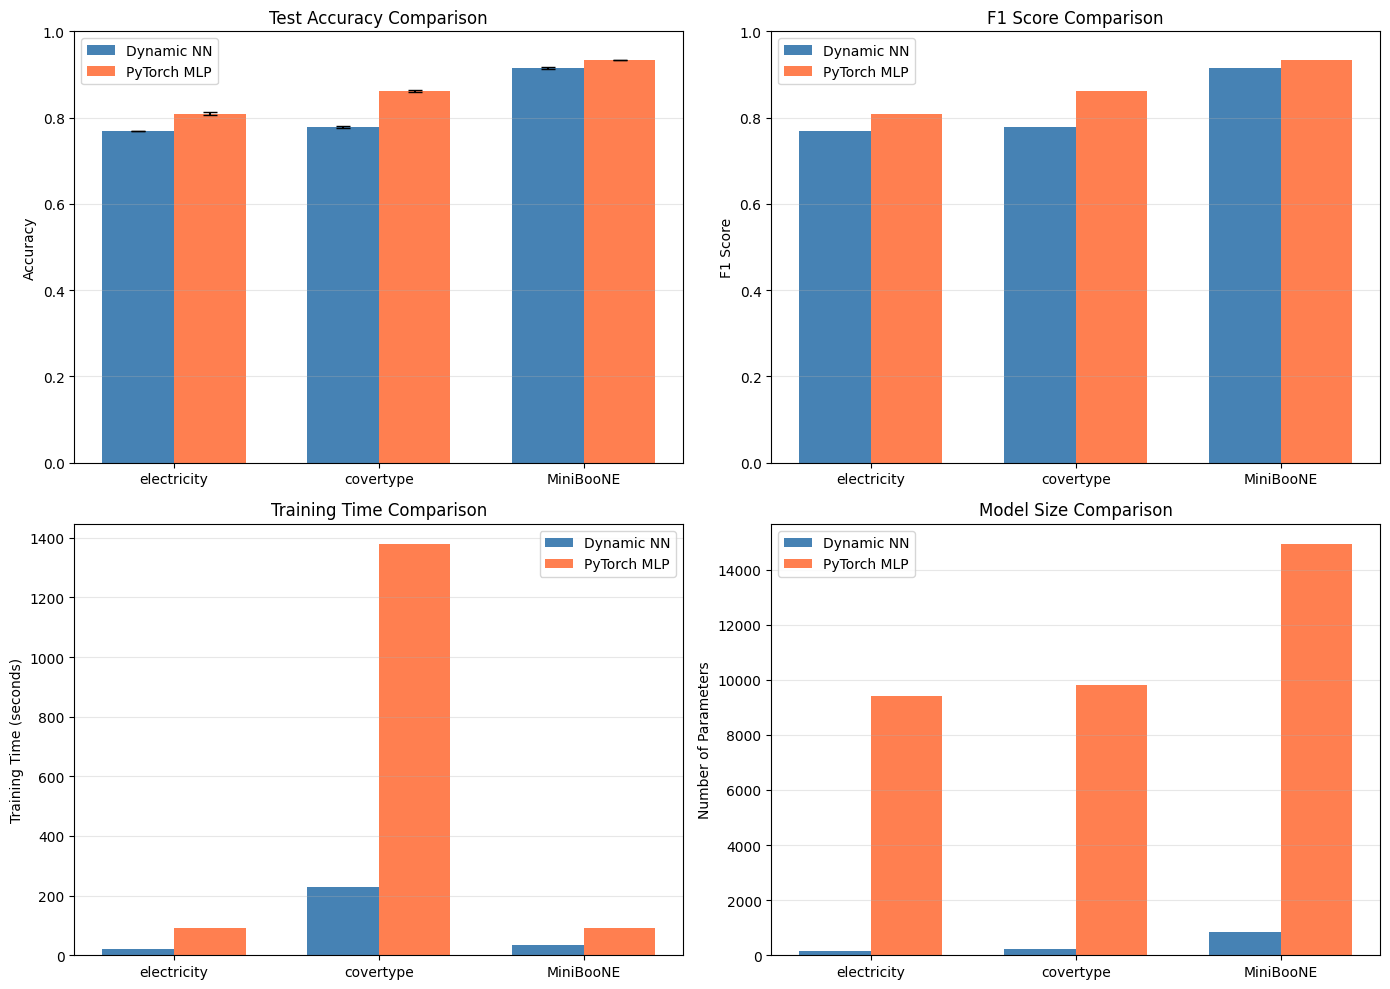


Figure saved to: benchmark_comparison.png


In [11]:
# Visualization: Accuracy comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = list(all_summaries.keys())
x = np.arange(len(datasets))
width = 0.35

# Extract metrics for plotting
dnn_acc = [all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Accuracy_mean'].values[0] for d in datasets]
mlp_acc = [all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Accuracy_mean'].values[0] for d in datasets]

dnn_acc_std = [all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Accuracy_std'].values[0] for d in datasets]
mlp_acc_std = [all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Accuracy_std'].values[0] for d in datasets]

dnn_f1 = [all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'F1_mean'].values[0] for d in datasets]
mlp_f1 = [all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'F1_mean'].values[0] for d in datasets]

dnn_time = [all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Train_Time_mean'].values[0] for d in datasets]
mlp_time = [all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Train_Time_mean'].values[0] for d in datasets]

dnn_params = [all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Parameters_int'].values[0] for d in datasets]
mlp_params = [all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Parameters_int'].values[0] for d in datasets]

# Plot 1: Accuracy
ax = axes[0, 0]
bars1 = ax.bar(x - width/2, dnn_acc, width, yerr=dnn_acc_std, label='Dynamic NN', color='steelblue', capsize=5)
bars2 = ax.bar(x + width/2, mlp_acc, width, yerr=mlp_acc_std, label='PyTorch MLP', color='coral', capsize=5)
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Plot 2: F1 Score
ax = axes[0, 1]
ax.bar(x - width/2, dnn_f1, width, label='Dynamic NN', color='steelblue')
ax.bar(x + width/2, mlp_f1, width, label='PyTorch MLP', color='coral')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Training Time
ax = axes[1, 0]
ax.bar(x - width/2, dnn_time, width, label='Dynamic NN', color='steelblue')
ax.bar(x + width/2, mlp_time, width, label='PyTorch MLP', color='coral')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Model Size (Parameters)
ax = axes[1, 1]
ax.bar(x - width/2, dnn_params, width, label='Dynamic NN', color='steelblue')
ax.bar(x + width/2, mlp_params, width, label='PyTorch MLP', color='coral')
ax.set_ylabel('Number of Parameters')
ax.set_title('Model Size Comparison')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: benchmark_comparison.png")

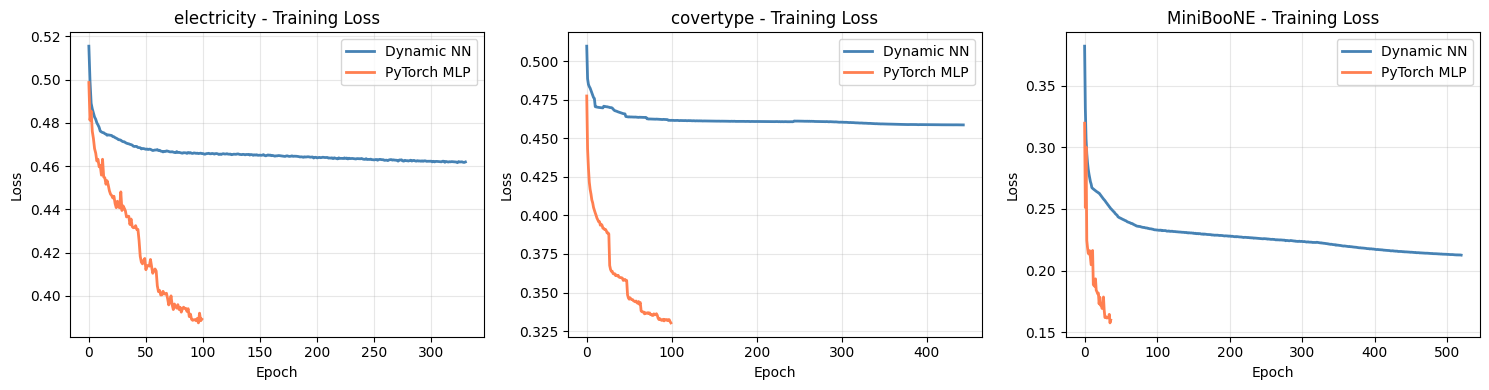


Figure saved to: training_curves.png


In [12]:
# Training curves comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, dataset_name in enumerate(datasets):
    ax = axes[idx]
    
    # Get first run's training history for each model
    dnn_history = all_detailed_results[dataset_name]['DNN'][0]['cost_history']
    mlp_history = all_detailed_results[dataset_name]['PyTorch_MLP'][0]['cost_history']
    
    ax.plot(dnn_history, label='Dynamic NN', color='steelblue', linewidth=2)
    ax.plot(mlp_history, label='PyTorch MLP', color='coral', linewidth=2)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{dataset_name} - Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: training_curves.png")

## 6. Summary & Analysis

In [13]:
print("="*80)
print("BENCHMARK SUMMARY: Dynamic Neural Network vs PyTorch MLP")
print("="*80)
print()

# Calculate overall statistics
dnn_wins = 0
mlp_wins = 0
ties = 0

print("Per-Dataset Results:")
print("-" * 60)

for dataset_name in datasets:
    summary = all_summaries[dataset_name]
    dnn_acc = summary.loc[summary['Model'] == 'DNN', 'Accuracy_mean'].values[0]
    mlp_acc = summary.loc[summary['Model'] == 'PyTorch_MLP', 'Accuracy_mean'].values[0]
    
    diff = dnn_acc - mlp_acc
    if abs(diff) < 0.01:
        winner = "TIE"
        ties += 1
    elif diff > 0:
        winner = "DNN"
        dnn_wins += 1
    else:
        winner = "MLP"
        mlp_wins += 1
    
    print(f"  {dataset_name:15s} | DNN: {dnn_acc:.4f} | MLP: {mlp_acc:.4f} | Winner: {winner}")

print("-" * 60)
print(f"\nOverall: DNN wins={dnn_wins}, MLP wins={mlp_wins}, Ties={ties}")

# Average metrics
avg_dnn_acc = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Accuracy_mean'].values[0] for d in datasets])
avg_mlp_acc = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Accuracy_mean'].values[0] for d in datasets])

avg_dnn_params = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Parameters_int'].values[0] for d in datasets])
avg_mlp_params = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Parameters_int'].values[0] for d in datasets])

avg_dnn_time = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'DNN', 'Train_Time_mean'].values[0] for d in datasets])
avg_mlp_time = np.mean([all_summaries[d].loc[all_summaries[d]['Model'] == 'PyTorch_MLP', 'Train_Time_mean'].values[0] for d in datasets])

print(f"\nAverage Metrics Across All Datasets:")
print(f"  {'Metric':<20} {'DNN':>15} {'PyTorch MLP':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<20} {avg_dnn_acc:>15.4f} {avg_mlp_acc:>15.4f}")
print(f"  {'Parameters':<20} {avg_dnn_params:>15,.0f} {avg_mlp_params:>15,.0f}")
print(f"  {'Training Time (s)':<20} {avg_dnn_time:>15.2f} {avg_mlp_time:>15.2f}")

print("\n" + "="*80)
print("KEY OBSERVATIONS:")
print("="*80)
print("""
1. ARCHITECTURE ADAPTATION:
   - DNN automatically adjusts its architecture during training
   - PyTorch MLP uses fixed architecture (128 -> 64 hidden layers)

2. MODEL SIZE:
   - DNN tends to find more compact representations
   - Parameter count varies based on data complexity

3. TRAINING BEHAVIOR:
   - DNN uses 4-phase training with automatic epoch estimation
   - PyTorch MLP uses standard training with early stopping

4. PRACTICAL CONSIDERATIONS:
   - DNN: Zero hyperparameter tuning required (only seed needed)
   - MLP: Requires choosing architecture, learning rate, etc.
""")

print("Benchmark complete!")

BENCHMARK SUMMARY: Dynamic Neural Network vs PyTorch MLP

Per-Dataset Results:
------------------------------------------------------------
  electricity     | DNN: 0.7691 | MLP: 0.8092 | Winner: MLP
  covertype       | DNN: 0.7786 | MLP: 0.8609 | Winner: MLP
  MiniBooNE       | DNN: 0.9155 | MLP: 0.9340 | Winner: MLP
------------------------------------------------------------

Overall: DNN wins=0, MLP wins=3, Ties=0

Average Metrics Across All Datasets:
  Metric                           DNN     PyTorch MLP
  --------------------------------------------------
  Accuracy                      0.8211          0.8680
  Parameters                       407          11,373
  Training Time (s)              95.43          520.11

KEY OBSERVATIONS:

1. ARCHITECTURE ADAPTATION:
   - DNN automatically adjusts its architecture during training
   - PyTorch MLP uses fixed architecture (128 -> 64 hidden layers)

2. MODEL SIZE:
   - DNN tends to find more compact representations
   - Parameter count